# Visual Classifier — Evaluation
Compares the **original** `capcheck/ai-image-detection` model against the
**fine-tuned** version (loaded from `./fine_tuned_model_delta/weight_delta.pt`)
on the test split of `deepfakesMSU/NTIRE-RobustAIGenDetection-val (streamed)`.

>  **Pre-requisite:** Run `visual_classifier_finetuning.ipynb` first to train the model
> and generate `./fine_tuned_model_delta/weight_delta.pt`.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
from datasets import load_dataset
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from visual_classifier import VisualClassifier

## 1. Load the Test Dataset

In [2]:
from datasets import load_from_disk

print('Loading combined dataset test split...')
test_dataset = load_from_disk('../../data/visual/combined_dataset')['test']
print(f'Loaded {len(test_dataset)} test examples.')

Loading combined dataset test split...


Loading dataset from disk:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded 3462 test examples.


## 2. Load Both Models

In [3]:
print("Loading original model...")
original_classifier = VisualClassifier(model_name_or_path="dima806/ai_vs_real_image_detection")
print("Original model ready.")

Loading original model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Original model ready.


In [4]:
print("Loading fine-tuned model from local weight delta...")
fine_tuned_classifier = VisualClassifier(
    model_name_or_path="dima806/ai_vs_real_image_detection",
    delta_path="./fine_tuned_model_delta/run_01_stage2A_ft_combined_weight_delta.pt",
)
print("Fine-tuned model ready.")

Loading fine-tuned model from local weight delta...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Applying weight delta from './fine_tuned_model_delta/run_01_stage2A_ft_combined_weight_delta.pt'...
Delta applied successfully.
Fine-tuned model ready.


In [5]:
print("Loading fine-tuned model")
fine_tuned_classifier = VisualClassifier(
    model_name_or_path="outputs/models/run_01_stage2A_ft_combined"
)
print("Fine-tuned model ready.")

Loading fine-tuned model


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Fine-tuned model ready.


## 3. Quick Sanity Check — Single Sample

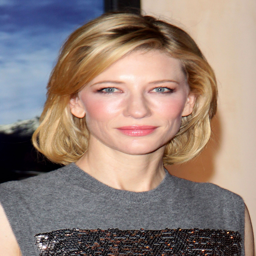

Ground Truth: Real
Original model:   {'prediction': 'AI Generated', 'confidence': 0.847, 'raw_label': 'fake', 'all_scores': {'REAL': 0.153, 'FAKE': 0.847}}
Fine-tuned model: {'prediction': 'Real', 'confidence': 0.9304, 'raw_label': 'human', 'all_scores': {'human': 0.9304, 'AI-generated': 0.0696}}


In [6]:
from IPython.display import display
import io
from PIL import Image

label_map = {0: 'Real', 1: 'AI Generated'}

# Since test_dataset is a streaming/iterable dataset, get the first element via iteration
sample_item = next(iter(test_dataset))
sample_image = sample_item['image']
sample_image = sample_image.convert('RGB')

sample_label = label_map.get(sample_item['label'], 'Unknown')

display(sample_image.resize((256, 256)))
print(f"Ground Truth: {sample_label}")
print(f"Original model:   {original_classifier.predict(sample_image)}")
print(f"Fine-tuned model: {fine_tuned_classifier.predict(sample_image)}")

## 4. Full Test-Set Evaluation
Runs inference for both models across the entire test split.

In [7]:
# Set a max sample limit if you want to evaluate faster
# Since test_dataset is a streaming/iterable dataset, we cannot use len() or direct indexing.
# We will iterate directly and stop after num_samples.
# num_samples = 20000
num_samples = 200

import io
from PIL import Image

orig_true_labels = []
orig_pred_labels = []

ft_true_labels = []
ft_pred_labels = []

count = 0
for item in tqdm(test_dataset, total=num_samples, desc="Evaluating both models"):
    if count >= num_samples:
        break
    
    img = item['image']
    if isinstance(img, bytes):
        img = Image.open(io.BytesIO(img))
    if img.mode != 'RGB':
        img = img.convert('RGB')

    true_label = label_map.get(item['label'], 'Unknown')

    # Original model
    orig_pred = original_classifier.predict(img)['prediction']
    orig_true_labels.append(true_label)
    orig_pred_labels.append(orig_pred)

    # Fine-tuned model
    ft_pred = fine_tuned_classifier.predict(img)['prediction']
    ft_true_labels.append(true_label)
    ft_pred_labels.append(ft_pred)
    
    count += 1

print("Evaluation complete.")

Evaluating both models:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluation complete.


## 5. Results — Original Model

In [8]:
print("=== Original Model ===")
print("\nClassification Report:")
print(classification_report(orig_true_labels, orig_pred_labels))

print("Confusion Matrix (rows=True, cols=Predicted):")
print(confusion_matrix(orig_true_labels, orig_pred_labels, labels=["Real", "AI Generated"]))

=== Original Model ===

Classification Report:
              precision    recall  f1-score   support

AI Generated       0.50      0.92      0.64        95
        Real       0.68      0.16      0.26       105

    accuracy                           0.52       200
   macro avg       0.59      0.54      0.45       200
weighted avg       0.59      0.52      0.44       200

Confusion Matrix (rows=True, cols=Predicted):
[[17 88]
 [ 8 87]]


## 6. Results — Fine-Tuned Model

In [9]:
print("=== Fine-Tuned Model ===")
print("\nClassification Report:")
print(classification_report(ft_true_labels, ft_pred_labels))

print("Confusion Matrix (rows=True, cols=Predicted):")
print(confusion_matrix(ft_true_labels, ft_pred_labels, labels=["Real", "AI Generated"]))

=== Fine-Tuned Model ===

Classification Report:
              precision    recall  f1-score   support

AI Generated       0.76      0.84      0.80        95
        Real       0.84      0.76      0.80       105

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200

Confusion Matrix (rows=True, cols=Predicted):
[[80 25]
 [15 80]]


## 7. Side-by-Side Accuracy Comparison

In [10]:
orig_acc = accuracy_score(orig_true_labels, orig_pred_labels)
ft_acc   = accuracy_score(ft_true_labels,   ft_pred_labels)

print(f"Original model accuracy : {orig_acc:.4f} ({orig_acc*100:.2f}%)")
print(f"Fine-tuned model accuracy: {ft_acc:.4f} ({ft_acc*100:.2f}%)")
print(f"Improvement             : {(ft_acc - orig_acc)*100:+.2f} pp")

Original model accuracy : 0.5200 (52.00%)
Fine-tuned model accuracy: 0.8000 (80.00%)
Improvement             : +28.00 pp
